Saving image.jp2 to image (1).jp2
Enter filter size (odd number): 13
1. Zero Padding
2. Replication
3. Reflect
Enter padding choice: 1
Enter sigma for Gaussian filter: 45


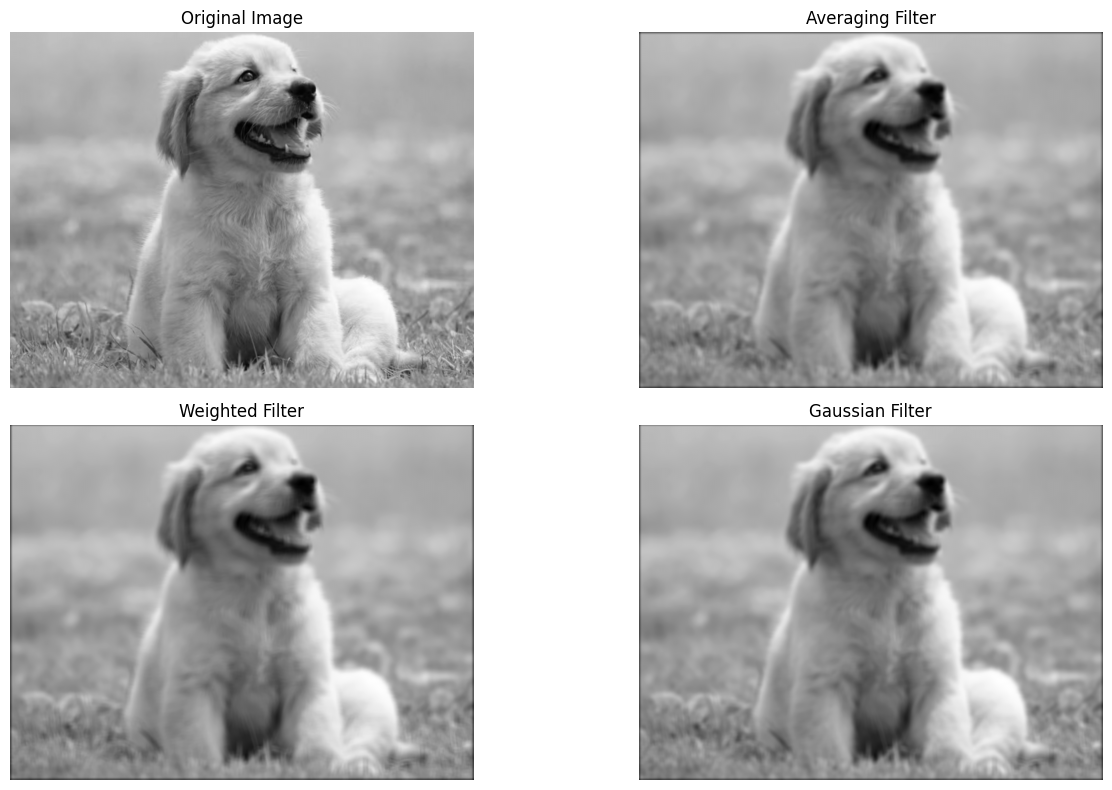

Averaging Filter Kernel:
[[0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716]
 [0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716]
 [0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716]
 [0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716]
 [0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716]
 [0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.00591716]
 [0.00591716 0.00591716 0.00591716 0.00591716 0.00591716 0.00591716
  0.005

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

filter_size = int(input("Enter filter size (odd number): "))

if filter_size % 2 == 0:
    raise ValueError("Filter size must be an odd number.")

print("1. Zero Padding")
print("2. Replication")
print("3. Reflect")

padding_choice = int(input("Enter padding choice: "))

if padding_choice == 1:
    border_type = cv2.BORDER_CONSTANT
elif padding_choice == 2:
    border_type = cv2.BORDER_REPLICATE
elif padding_choice == 3:
    border_type = cv2.BORDER_REFLECT
else:
    raise ValueError("Invalid padding choice.")

sigma = float(input("Enter sigma for Gaussian filter: "))

averaging_kernel = np.ones(
    (filter_size, filter_size),
    dtype=np.float32
) / (filter_size * filter_size)

averaging_img = cv2.filter2D(
    img, -1, averaging_kernel, borderType=border_type
)

center = filter_size // 2

weighted_kernel = np.zeros(
    (filter_size, filter_size),
    dtype=np.float32
)

for i in range(filter_size):
    for j in range(filter_size):
        x = i - center
        y = j - center
        weighted_kernel[i, j] = max(abs(x), abs(y))

weighted_kernel[center, center] = 1
weighted_kernel = weighted_kernel / np.sum(weighted_kernel)

weighted_img = cv2.filter2D(
    img, -1, weighted_kernel, borderType=border_type
)

gaussian_img = cv2.GaussianBlur(
    img,
    (filter_size, filter_size),
    sigmaX=sigma,
    sigmaY=sigma,
    borderType=border_type
)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(averaging_img, cmap="gray")
plt.title("Averaging Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(weighted_img, cmap="gray")
plt.title("Weighted Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_img, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Averaging Filter Kernel:")
print(averaging_kernel)

print("\nWeighted Filter Kernel:")
print(weighted_kernel)

print("\nFilter Size:", filter_size)
print("Sigma:", sigma)

Saving image.jp2 to image (2).jp2
Enter filter size (odd number): 15
1. Zero Padding
2. Replication
3. Reflect
Enter padding choice: 2
Enter sigma for Gaussian filter: 56


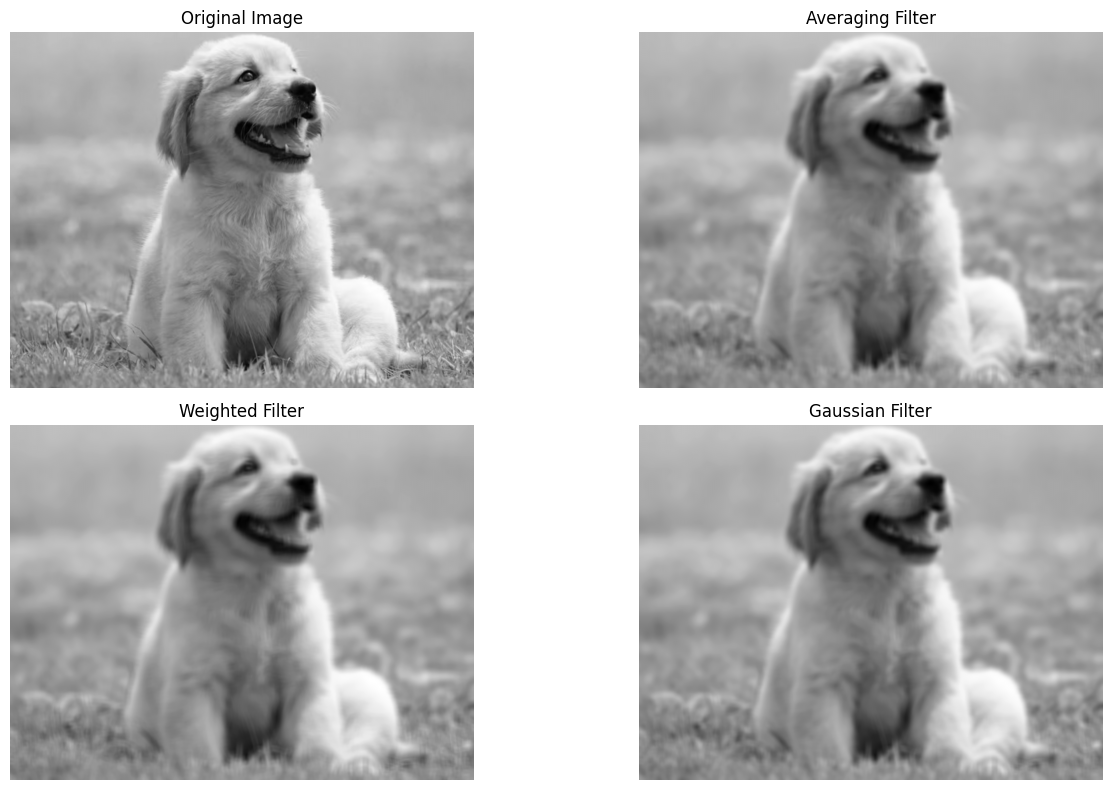

Averaging Filter Kernel:
[[0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

filter_size = int(input("Enter filter size (odd number): "))

if filter_size % 2 == 0:
    raise ValueError("Filter size must be an odd number.")

print("1. Zero Padding")
print("2. Replication")
print("3. Reflect")

padding_choice = int(input("Enter padding choice: "))

if padding_choice == 1:
    border_type = cv2.BORDER_CONSTANT
elif padding_choice == 2:
    border_type = cv2.BORDER_REPLICATE
elif padding_choice == 3:
    border_type = cv2.BORDER_REFLECT
else:
    raise ValueError("Invalid padding choice.")

sigma = float(input("Enter sigma for Gaussian filter: "))

averaging_kernel = np.ones(
    (filter_size, filter_size),
    dtype=np.float32
) / (filter_size * filter_size)

averaging_img = cv2.filter2D(
    img, -1, averaging_kernel, borderType=border_type
)

center = filter_size // 2

weighted_kernel = np.zeros(
    (filter_size, filter_size),
    dtype=np.float32
)

for i in range(filter_size):
    for j in range(filter_size):
        x = i - center
        y = j - center
        weighted_kernel[i, j] = max(abs(x), abs(y))

weighted_kernel[center, center] = 1
weighted_kernel = weighted_kernel / np.sum(weighted_kernel)

weighted_img = cv2.filter2D(
    img, -1, weighted_kernel, borderType=border_type
)

gaussian_img = cv2.GaussianBlur(
    img,
    (filter_size, filter_size),
    sigmaX=sigma,
    sigmaY=sigma,
    borderType=border_type
)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(averaging_img, cmap="gray")
plt.title("Averaging Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(weighted_img, cmap="gray")
plt.title("Weighted Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_img, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Averaging Filter Kernel:")
print(averaging_kernel)

print("\nWeighted Filter Kernel:")
print(weighted_kernel)

print("\nFilter Size:", filter_size)
print("Sigma:", sigma)

Saving image.jp2 to image (3).jp2
Enter filter size (odd number): 15
1. Zero Padding
2. Replication
3. Reflect
Enter padding choice: 3
Enter sigma for Gaussian filter: 56


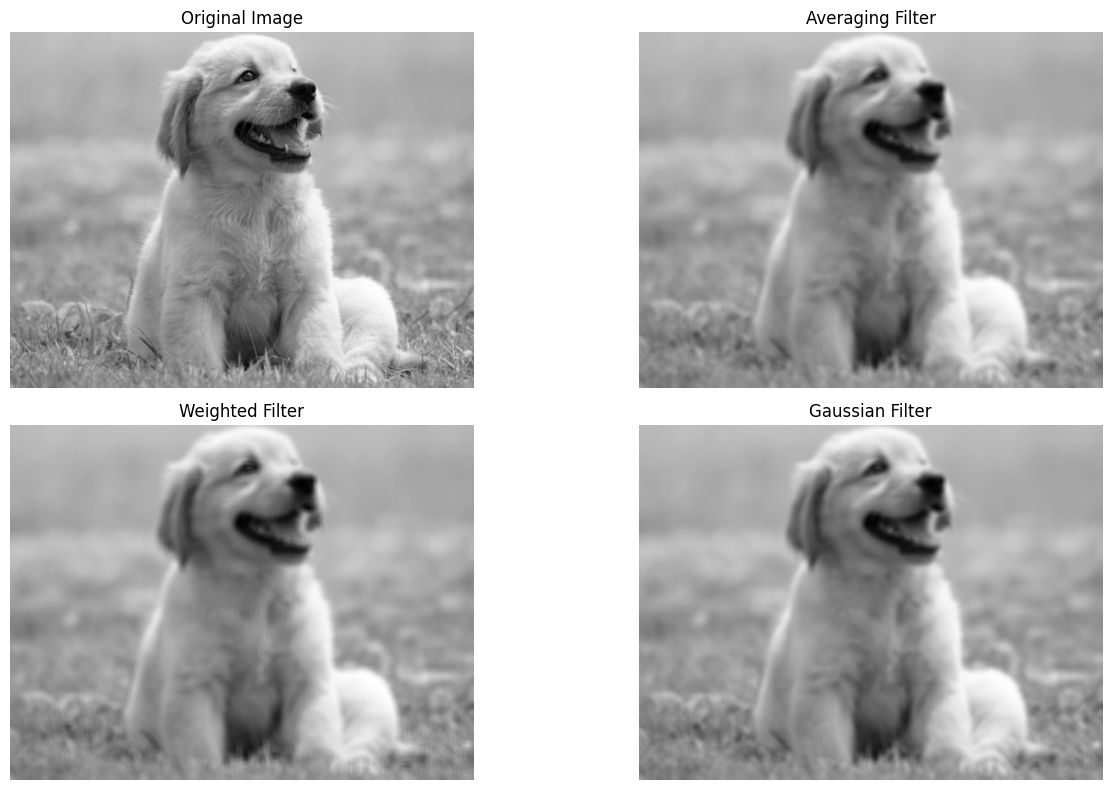

Averaging Filter Kernel:
[[0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

filter_size = int(input("Enter filter size (odd number): "))

if filter_size % 2 == 0:
    raise ValueError("Filter size must be an odd number.")

print("1. Zero Padding")
print("2. Replication")
print("3. Reflect")

padding_choice = int(input("Enter padding choice: "))

if padding_choice == 1:
    border_type = cv2.BORDER_CONSTANT
elif padding_choice == 2:
    border_type = cv2.BORDER_REPLICATE
elif padding_choice == 3:
    border_type = cv2.BORDER_REFLECT
else:
    raise ValueError("Invalid padding choice.")

sigma = float(input("Enter sigma for Gaussian filter: "))

averaging_kernel = np.ones(
    (filter_size, filter_size),
    dtype=np.float32
) / (filter_size * filter_size)

averaging_img = cv2.filter2D(
    img, -1, averaging_kernel, borderType=border_type
)

center = filter_size // 2

weighted_kernel = np.zeros(
    (filter_size, filter_size),
    dtype=np.float32
)

for i in range(filter_size):
    for j in range(filter_size):
        x = i - center
        y = j - center
        weighted_kernel[i, j] = max(abs(x), abs(y))

weighted_kernel[center, center] = 1
weighted_kernel = weighted_kernel / np.sum(weighted_kernel)

weighted_img = cv2.filter2D(
    img, -1, weighted_kernel, borderType=border_type
)

gaussian_img = cv2.GaussianBlur(
    img,
    (filter_size, filter_size),
    sigmaX=sigma,
    sigmaY=sigma,
    borderType=border_type
)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(averaging_img, cmap="gray")
plt.title("Averaging Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(weighted_img, cmap="gray")
plt.title("Weighted Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_img, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Averaging Filter Kernel:")
print(averaging_kernel)

print("\nWeighted Filter Kernel:")
print(weighted_kernel)

print("\nFilter Size:", filter_size)
print("Sigma:", sigma)